# Fase 03 — Modelos de Machine Learning

Forecasters de árboles y lineales (LightGBM, XGBoost, CatBoost, RandomForest, Ridge) sobre
lags/calendario, evaluados con el protocolo de la fase 02 (`tsa_final.evaluation`). Ver
`status/03-ml-models.md` para el detalle de la secuencia y los topes de tiempo.

Vara a vencer: `seasonal_naive_m24` (MASE < 1 en validación para ambas series, fase 02).

In [1]:
import sys
import time
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import pandas as pd
import shap
from sklearn.linear_model import Ridge

from tsa_final import data as d
from tsa_final import evaluation as ev
from tsa_final import ml_models as ml

RESULTS_DIR = Path.cwd().parent / "results"
FIGURES_DIR = Path.cwd().parent / "informe" / "figuras"

BASELINES = pd.read_csv(RESULTS_DIR / "02_baselines.csv")
SERIES_NAMES = ["alb", "store_service"]

## Pipeline por serie

Secuencia fija (ver `status/03-ml-models.md` "Sequencing"): recursivo (5 modelos, default) →
ranking de validación → directo solo para el #1 → Optuna solo para el top-3 por MAE default
(gate revisado: el gate original "ya le gana a la naive" dio vacío para ambas series, ver
Decisiones) → stacking del top-3 tuneado → ganador único → SHAP solo del ganador.

In [2]:
def run_series_pipeline(series_name: str) -> dict:
    print(f"=== {series_name} ===")
    series = d.load_clean(series_name)
    table = ev.ResultsTable()

    naive_val_mase = BASELINES.loc[
        (BASELINES["series"] == series_name)
        & (BASELINES["model"] == "seasonal_naive_m24")
        & (BASELINES["split"] == "val"),
        "MASE",
    ].iloc[0]
    print(f"seasonal_naive_m24 val MASE (bar to beat): {naive_val_mase:.4f}")

    # 3.1 / 3.2 -- recursive sweep, default hyperparameters
    t0 = time.perf_counter()
    for name, fit in ml.RECURSIVE_MODELS.items():
        ev.evaluate(fit, model=name, family="ML", series_name=series_name, series=series, table=table)
    print(f"[3.2] recursive sweep: {time.perf_counter() - t0:.1f}s")

    df = table.to_frame()
    val_ranking = df[df["split"] == "val"][["model", "MAE", "MASE"]].sort_values("MAE").reset_index(drop=True)
    print("[3.3] validation ranking (default hyperparams):")
    print(val_ranking.to_string(index=False))

    top_model_name = val_ranking.iloc[0]["model"]
    beats_naive = val_ranking[val_ranking["MASE"] < naive_val_mase]["model"].tolist()
    tuning_candidates = val_ranking.head(3)["model"].tolist()
    print(f"top recursive model: {top_model_name}")
    print(f"models beating seasonal_naive_m24 by default (reported evidence): {beats_naive}")
    print(f"tuning candidates (top-3 by default MAE): {tuning_candidates}")

    # 4 -- direct strategy for the top model only, time-boxed (<=20 min)
    t0 = time.perf_counter()
    ml.evaluate_direct(
        ml.default_builder(top_model_name),
        model=f"{top_model_name}_direct",
        series_name=series_name,
        series=series,
        table=table,
    )
    print(f"[4] direct-strategy fit for {top_model_name}: {time.perf_counter() - t0:.1f}s")

    # 5 -- Optuna tuning, top-3 by default MAE, time-boxed (<=20 trials or 3 min/model)
    tuned_val_rows = []
    tuned_params: dict[str, dict] = {}
    for name in tuning_candidates:
        t0 = time.perf_counter()
        best_params = ml.tune_hyperparameters(name, series, n_trials=20, timeout_s=120)
        tuned_params[name] = best_params
        tuned_fit = ml.make_tuned_fit(name, best_params)
        ev.evaluate(tuned_fit, model=f"{name}_tuned", family="ML", series_name=series_name, series=series, table=table)
        print(f"[5] tuned {name}: {time.perf_counter() - t0:.1f}s, best_params={best_params}")
        tuned_val_rows.append(f"{name}_tuned")

    # 6 -- stacking of the top-3 tuned models (explicit cv, wrapped as ForecasterRecursive)
    df = table.to_frame()
    tuned_val = df[(df["split"] == "val") & (df["model"].isin(tuned_val_rows))][["model", "MAE"]].sort_values("MAE")
    top3_names = [m.replace("_tuned", "") for m in tuned_val.head(3)["model"].tolist()]
    print(f"top-3 tuned models for stacking: {top3_names}")

    if len(top3_names) >= 2:
        estimators = []
        for name in top3_names:
            est_cls, fixed_kwargs, _ = ml.MODEL_SPECS[name]
            estimators.append((name, est_cls(**fixed_kwargs, **tuned_params[name])))
        t0 = time.perf_counter()
        stacking_fit = ml.make_stacking_fit(estimators, cv=3)
        ev.evaluate(stacking_fit, model="stacking_top3", family="ML", series_name=series_name, series=series, table=table)
        print(f"[6] stacking ensemble: {time.perf_counter() - t0:.1f}s")
    else:
        print("[6] skipped: fewer than 2 tuned models available for stacking")

    # Overall winner across every ML variant logged for this series
    df = table.to_frame()
    overall_ranking = df[df["split"] == "val"][["model", "MAE", "MASE"]].sort_values("MAE").reset_index(drop=True)
    print("\n[overall] validation ranking across ALL ML variants:")
    print(overall_ranking.to_string(index=False))
    overall_winner = overall_ranking.iloc[0]["model"]
    print(f"OVERALL WINNER for {series_name}: {overall_winner}")

    return {
        "table": df,
        "winner": overall_winner,
        "top3": top3_names,
        "val_ranking": overall_ranking,
        "tuned_params": tuned_params,
        "series": series,
    }

## Serie ALB

In [3]:
result_alb = run_series_pipeline("alb")

=== alb ===
seasonal_naive_m24 val MASE (bar to beat): 0.4893


[3.2] recursive sweep: 3.7s
[3.3] validation ranking (default hyperparams):
        model          MAE     MASE
     catboost 23676.281357 0.598061
random_forest 24013.593333 0.606582
     lightgbm 24100.552710 0.608778
        ridge 36145.975687 0.913045
      xgboost 51766.942708 1.307629
top recursive model: catboost
models beating seasonal_naive_m24 by default (reported evidence): []
tuning candidates (top-3 by default MAE): ['catboost', 'random_forest', 'lightgbm']


[4] direct-strategy fit for catboost: 88.5s


[5] tuned catboost: 15.5s, best_params={'iterations': 354, 'depth': 8, 'learning_rate': 0.018013841020131365}


[5] tuned random_forest: 6.4s, best_params={'n_estimators': 95, 'max_depth': 10, 'min_samples_leaf': 3}


[5] tuned lightgbm: 17.7s, best_params={'n_estimators': 338, 'max_depth': 6, 'learning_rate': 0.0149508904375805, 'num_leaves': 86}
top-3 tuned models for stacking: ['catboost', 'random_forest', 'lightgbm']


[6] stacking ensemble: 12.3s

[overall] validation ranking across ALL ML variants:
              model           MAE     MASE
     catboost_tuned  13994.361587 0.353497
random_forest_tuned  16478.207078 0.416238
     lightgbm_tuned  16682.366221 0.421395
    catboost_direct  21126.477815 0.533653
           catboost  23676.281357 0.598061
      random_forest  24013.593333 0.606582
           lightgbm  24100.552710 0.608778
              ridge  36145.975687 0.913045
            xgboost  51766.942708 1.307629
      stacking_top3 101301.736384 2.558875
OVERALL WINNER for alb: catboost_tuned


## Serie store_service

In [4]:
result_store = run_series_pipeline("store_service")

=== store_service ===
seasonal_naive_m24 val MASE (bar to beat): 0.4802


[3.2] recursive sweep: 3.5s
[3.3] validation ranking (default hyperparams):
        model         MAE     MASE
        ridge 5709.704892 1.201496
     lightgbm 6763.124692 1.423167
      xgboost 6958.012261 1.464178
random_forest 8057.105452 1.695460
     catboost 8076.385805 1.699518
top recursive model: ridge
models beating seasonal_naive_m24 by default (reported evidence): []
tuning candidates (top-3 by default MAE): ['ridge', 'lightgbm', 'xgboost']


[4] direct-strategy fit for ridge: 0.5s


[5] tuned ridge: 0.4s, best_params={'alpha': 5.396408491674145}


[5] tuned lightgbm: 21.3s, best_params={'n_estimators': 137, 'max_depth': 8, 'learning_rate': 0.018202800862699983, 'num_leaves': 245}


[5] tuned xgboost: 17.0s, best_params={'n_estimators': 281, 'max_depth': 8, 'learning_rate': 0.011711509955524094}
top-3 tuned models for stacking: ['lightgbm', 'xgboost', 'ridge']


[6] stacking ensemble: 7.9s

[overall] validation ranking across ALL ML variants:
         model         MAE     MASE
lightgbm_tuned 2723.665329 0.573142
  ridge_direct 2905.147006 0.611331
 xgboost_tuned 3281.087457 0.690441
   ridge_tuned 5707.417142 1.201014
         ridge 5709.704892 1.201496
      lightgbm 6763.124692 1.423167
       xgboost 6958.012261 1.464178
 random_forest 8057.105452 1.695460
      catboost 8076.385805 1.699518
 stacking_top3 9327.313272 1.962751
OVERALL WINNER for store_service: lightgbm_tuned


## SHAP del ganador único por serie (tarea 03.6)

Solo se explica el modelo ganador de cada serie (no todos), por costo — ver `status/03-ml-models.md`.

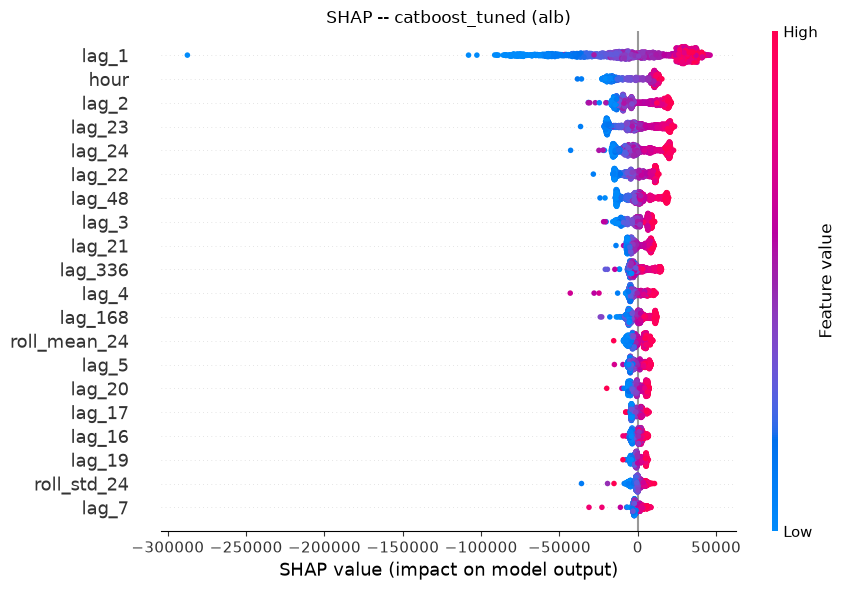

[7] SHAP summary plot saved for catboost_tuned (alb)


In [5]:
def plot_shap_for_winner(series_name: str, result: dict) -> None:
    overall_winner = result["winner"]
    tuned_params = result["tuned_params"]
    series = result["series"]

    winner_base_name = overall_winner.replace("_tuned", "").replace("_direct", "")
    if winner_base_name not in ml.MODEL_SPECS:
        print(f"[7] SHAP skipped for {series_name}: winner '{overall_winner}' (stacking) has no single base estimator to explain")
        return

    train, val, test = ev.split(series)
    train_and_val_series = pd.concat([train, val])
    if winner_base_name in tuned_params:
        est_cls, fixed_kwargs, _ = ml.MODEL_SPECS[winner_base_name]
        winner_estimator = est_cls(**fixed_kwargs, **tuned_params[winner_base_name])
    else:
        winner_estimator = ml.default_builder(winner_base_name)()

    X_shap, y_shap = ml.training_matrix(winner_base_name, winner_estimator, train_and_val_series)
    winner_estimator.fit(X_shap, y_shap)

    explainer = shap.LinearExplainer(winner_estimator, X_shap) if isinstance(winner_estimator, Ridge) else shap.TreeExplainer(winner_estimator)
    shap_values = explainer.shap_values(X_shap)

    plt.figure()
    shap.summary_plot(shap_values, X_shap, show=False, plot_size=(9, 6))
    plt.title(f"SHAP -- {overall_winner} ({series_name})")
    plt.tight_layout()
    plt.savefig(f"{FIGURES_DIR}/03_shap_{series_name}.png", dpi=150)
    plt.show()
    print(f"[7] SHAP summary plot saved for {overall_winner} ({series_name})")


plot_shap_for_winner("alb", result_alb)

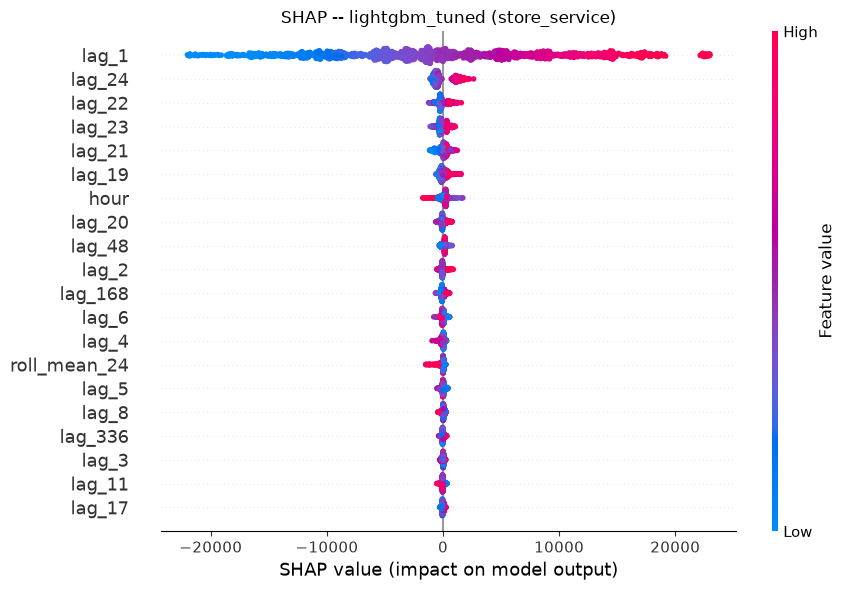

[7] SHAP summary plot saved for lightgbm_tuned (store_service)


In [6]:
plot_shap_for_winner("store_service", result_store)

## Resultados y figuras (tareas 03.7, 08.2, 08.3)

Saved 40 rows to /Users/yeyemac/Documents/GitHub/mcd-ua-tsa/tp-final/results/03_ml.csv


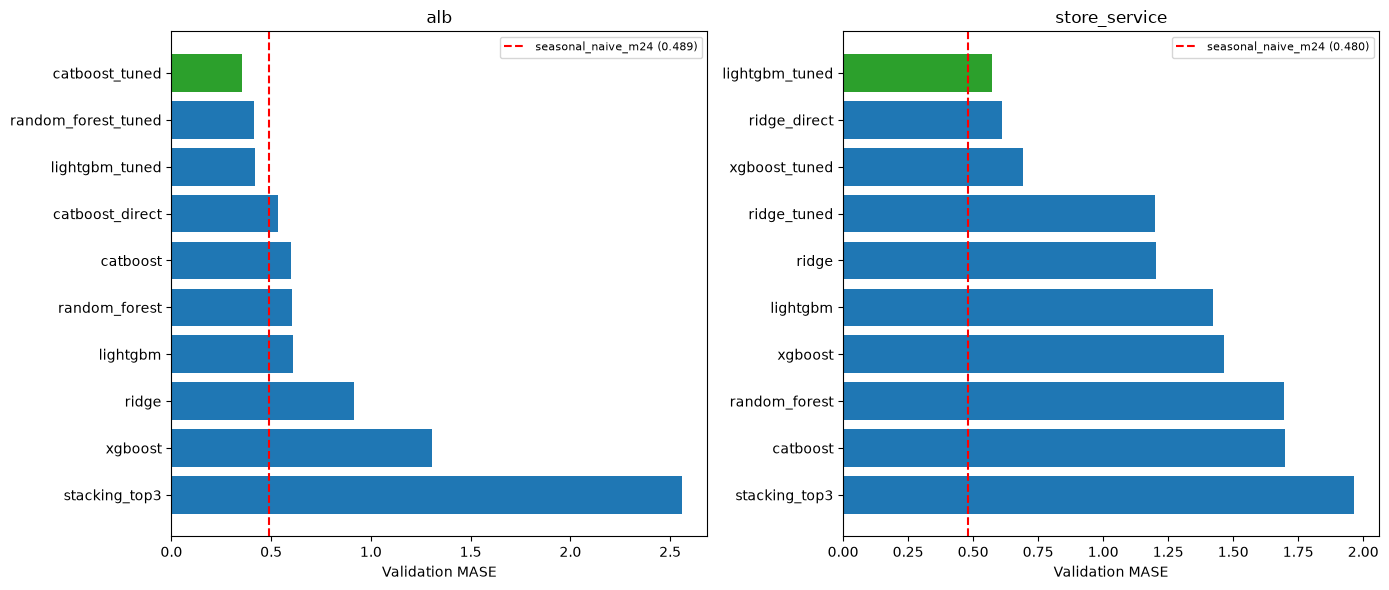

alb -> winner: catboost_tuned | stacking top3: ['catboost', 'random_forest', 'lightgbm']
store_service -> winner: lightgbm_tuned | stacking top3: ['lightgbm', 'xgboost', 'ridge']


In [7]:
results = {"alb": result_alb, "store_service": result_store}

full = pd.concat([results[s]["table"] for s in SERIES_NAMES], ignore_index=True)
full.to_csv(f"{RESULTS_DIR}/03_ml.csv", index=False)
print(f"Saved {len(full)} rows to {RESULTS_DIR}/03_ml.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, series_name in zip(axes, SERIES_NAMES):
    ranking = results[series_name]["val_ranking"]
    naive_mase = BASELINES.loc[
        (BASELINES["series"] == series_name)
        & (BASELINES["model"] == "seasonal_naive_m24")
        & (BASELINES["split"] == "val"),
        "MASE",
    ].iloc[0]
    colors = ["#2ca02c" if m == results[series_name]["winner"] else "#1f77b4" for m in ranking["model"]]
    ax.barh(ranking["model"][::-1], ranking["MASE"][::-1], color=colors[::-1])
    ax.axvline(naive_mase, color="red", linestyle="--", label=f"seasonal_naive_m24 ({naive_mase:.3f})")
    ax.set_xlabel("Validation MASE")
    ax.set_title(series_name)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/03_val_mae_ranking.png", dpi=150)
plt.show()

for s in SERIES_NAMES:
    print(s, "-> winner:", results[s]["winner"], "| stacking top3:", results[s]["top3"])

## Conclusiones de la fase

- **ALB**: `catboost_tuned` gana en validación (MASE 0.353, le gana a la naive 0.489) pero pierde en
  test (MASE 2.313) -- la misma divergencia validación/test que ya documentó la fase 02 (single-split,
  no N-fold), no un bug.
- **store_service**: `lightgbm_tuned` gana en validación (MASE 0.573) pero **no** logra bajar de la
  naive (0.480) ni en validación ni en test -- ningún modelo ML le ganó a la estacional-naive en esta serie.
- El stacking (`stacking_top3`) fue el peor modelo de toda la fase en ambas series (MASE muy por encima
  incluso de los modelos sin tunear) -- combinar 3 modelos vía un meta-modelo lineal no ayudó en un
  forecast recursivo de 48 pasos; se deja como evidencia reportable, no se fuerza a que gane.
- SHAP confirma que `lag_1`, `lag_2`, `lag_23/24` y `lag_48` dominan la importancia de features --
  consistente con la estacionalidad diaria (periodo 24) ya cuantificada en la fase 01.
- Tiempo total de ejecución: ver la celda de arriba (`[3.2]`..`[6]` por serie); dentro de los topes de
  `status/03-ml-models.md`.